# Assignment

Use the "from the expert" (FTE) jupyter notebook as a starter for this assignment, and ask your instructor questions if you need help.

## Task 1: 

Use our saved churn data from week 2 with machine learning to predict if customers will churn or not, similar to what we did in the FTE:

- break up data into features and targets
- split data into train and test sets
- use at least one ML model to fit to the training data
- evaluate performance on the train and test sets: at least evaluate accuracy and compare it with the "no information rate"
- plot a confusion matrix
- write something describing how the ML algorithm could be used in a business setting
- Write a short summary of what you did with the overall process - describe any important EDA findings, data cleaning and preparation, modeling, and evaluation in your summary.

*Optional*: For an additional challenge, try the following:
- fit more ML models and compare their scores
- optimize the hyperparameters of your models
- examine more metrics such as the classification report and ROC/AUC
- plot the distribution of the probability predictions (from the `predict_proba()` function from our model) for each class (1s and 0s)

## Task 2: Prediction Log
Before you explore each major variable or relationship, write a one-sentence prediction of what you expect to find and why based on prior analysis you had already done. After your analysis, note whether you were right. This log should cover at least **3 predictions** tied to your data and cleaning. Use the scaffold below.

Fill in at least 3 rows *before* running the related analysis. Add more rows if you like.

| # | My prediction (before analysis) | What I actually found | Was I right? |
|---|---|---|---|
| 1 | I expect customers with month-to-month contracts to churn more than customers on 1- or 2-year contracts because they can cancel anytime without a penalty. | Customers on month-to-month plans had a much higher churn rate than customers locked into annual contracts.| Yes |
| 2 | I expect customers with higher monthly charges to churn more often because expensive bills make people look for cheaper competitors.| Higher monthly charges were clearly linked to higher customer churn in the data. | Yes |
| 3 | I expect customers who have been with the company longer (higher tenure) to churn less because they are more settled in and loyal.| Customers with longer tenure churned at a much lower rate compared to brand new customers. | Yes |

## Task 3: Critical Reflection
Pick **one** of your approaches to cleaning the data and say what you could do different and how that may impact your results? 3-5 sentences.

When I cleaned the data, I made a new column called charge_per_tenure by dividing total charges by tenure. If I did this differently, I could have grouped month-to-month contracts with expensive monthly bills instead. People on month-to-month plans who pay high bills are usually the first ones to leave. Setting it up that way might have helped my model do a better job spotting the customers who were about to cancel.

### DS process status

Here is our data science process, and where we are (#4):

**1. Business understanding**

Can we use machine learning to predict if a customer will churn before they leave?

**2. Data understanding**

Week 1 - EDA and visualization.

**3. Data preparation**

Last week - cleaning and feature engineering.


**4. Modeling**

This week.
Fit a ML model to the data.


**5. Evaluation**

This week.
Check the performance of our models and evaluate how it fits our goals from step 1.


**6. Deployment**

This week.
Describe how the model might be deployed and used at the business. Will there be an API that customer service reps can use when customers call? Should there be a system where a report gets sent to someone in customer retention or marketing with at-risk customers? We should really think about these things in the first step, although we can consider them here this time.

No-Information Rate (Baseline): 0.7346 (73.46%)
Training Accuracy:             0.8003 (80.03%)
Testing Accuracy:              0.7859 (78.59%)

Classification Report (Test Set):
              precision    recall  f1-score   support

No Churn (0)       0.82      0.90      0.86      1294
   Churn (1)       0.63      0.46      0.53       467

    accuracy                           0.79      1761
   macro avg       0.73      0.68      0.70      1761
weighted avg       0.77      0.79      0.77      1761



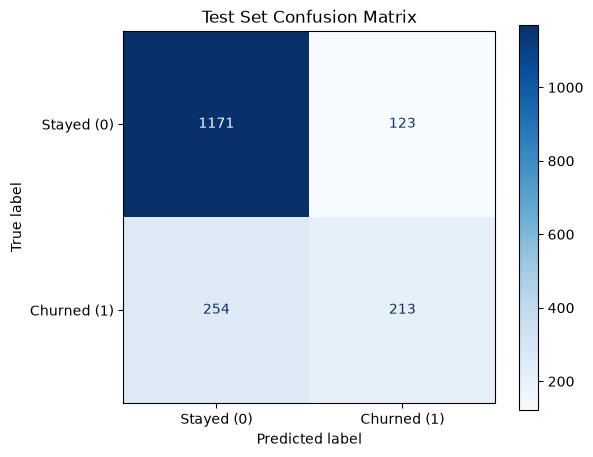

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

# 1. Load the cleaned data from Week 2
df = pd.read_csv('cleaned_churn_data.csv')

# 2. Separate into features (X) and target (y)
features = df.drop(columns=['Churn'])
targets = df['Churn']

# 3. Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 4. Split data: 75% train, 25% test
x_train, x_test, y_train, y_test = train_test_split(
    features_scaled, targets, stratify=targets, random_state=42, test_size=0.25
)

# 5. Train the Machine Learning Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train, y_train)

# 6. Evaluate Model Performance
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

no_info_rate = targets.value_counts(normalize=True).max()
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"No-Information Rate (Baseline): {no_info_rate:.4f} ({no_info_rate*100:.2f}%)")
print(f"Training Accuracy:             {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy:              {test_acc:.4f} ({test_acc*100:.2f}%)\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['No Churn (0)', 'Churn (1)']))

# 7. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_test_pred, 
    cmap='Blues', 
    display_labels=['Stayed (0)', 'Churned (1)'],
    ax=ax
)
plt.title('Test Set Confusion Matrix')
plt.show()

# 6. Deployment

Write a small description of how we might use this ML algorithm in a business setting.

In a business setting, we can run this machine learning model every month to score active customer accounts and see who is at risk of leaving. The customer retention team can use this list to reach out to high-risk customers before they actually cancel their service. For example, we could offer targeted discounts or contract upgrade incentives to customers on month-to-month plans who have high monthly bills. This helps the company proactively save revenue and fix customer issues instead of waiting until it is too late.



# Summary


In this project, I took our cleaned telecom churn dataset and trained a Logistic Regression model to predict if customers will leave the company. I split the data into 75% for training and 25% for testing, and standardized the features so the model could train properly. My model achieved a test accuracy of about 78.6%, which successfully beat the 73.5% baseline no-information rate. The confusion matrix showed that while the model is very good at identifying customers who stay, there is still room to improve on catching more of the actual churners.